# Task 2: Build a Linear Graph

In this task, a simple linear workflow is implemented using LangGraph. The workflow consists of four processing nodes: Plan, Retrieve, Generate, and Format.
The purpose of this task is to understand how nodes are connected using normal edges and how a shared state is passed from one node to the next. The graph will be compiled and executed on a sample question, and the state will be printed after each node to verify that the information is updated correctly.


In [1]:
%pip install -U langgraph langchain langchain-core langchain-google-genai
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

print("LangGraph imported successfully!")
# Created State
class GraphState(TypedDict):
    question: str
    plan: str
    retrieved_info: str
    draft: str
    final_answer: str
# Test
print("State schema created successfully!")
print(GraphState.__annotations__)

Note: you may need to restart the kernel to use updated packages.
LangGraph imported successfully!
State schema created successfully!
{'question': <class 'str'>, 'plan': <class 'str'>, 'retrieved_info': <class 'str'>, 'draft': <class 'str'>, 'final_answer': <class 'str'>}


![mermaid-diagram (5).png](<attachment:mermaid-diagram (5).png>)
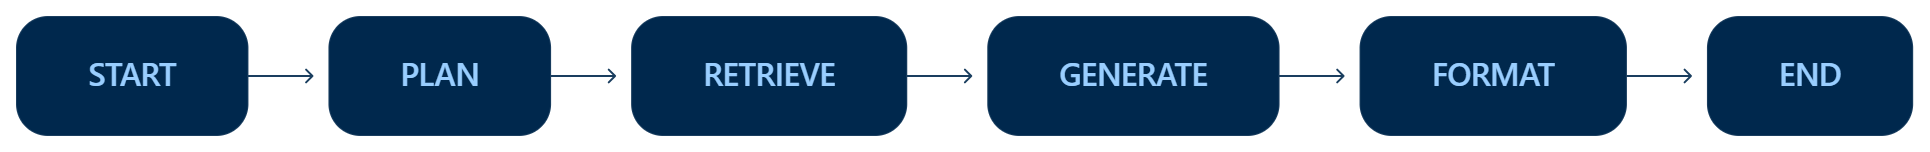

In [2]:
# Plan Node 
def plan_node(state: GraphState):
    question = state["question"]

    plan = (
        f"To answer the question '{question}', "
        "first identify the main topic, then collect relevant information, "
        "and finally generate a clear response."
    )

    return {
        "plan": plan
    }

In [3]:
# Retrieve Node
def retrieve_node(state: GraphState):
    question = state["question"]

    retrieved_info = (
        f"Relevant information was retrieved for the question: {question}"
    )

    return {
        "retrieved_info": retrieved_info
    }

In [4]:
# Generate Node
def generate_node(state: GraphState):
    draft = (
        f"Question: {state['question']}\n"
        f"Plan: {state['plan']}\n"
        f"Information: {state['retrieved_info']}\n\n"
        "Based on the available information, this is the generated answer."
    )

    return {
        "draft": draft
    }

In [5]:
# Format Node
def format_node(state: GraphState):
    final_answer = (
        "FINAL ANSWER\n"
        "-------------\n"
        + state["draft"]
    )

    return {
        "final_answer": final_answer
    }

In [6]:
graph_builder = StateGraph(GraphState)

graph_builder.add_node("plan", plan_node)
graph_builder.add_node("retrieve", retrieve_node)
graph_builder.add_node("generate", generate_node)
graph_builder.add_node("format", format_node)

print("Nodes added successfully!")

Nodes added successfully!


In [7]:
graph_builder = StateGraph(GraphState)

graph_builder.add_node("plan", plan_node)
graph_builder.add_node("retrieve", retrieve_node)
graph_builder.add_node("generate", generate_node)
graph_builder.add_node("format", format_node)

print("Nodes added successfully!")

Nodes added successfully!


In [8]:
graph_builder.add_edge(START, "plan")
graph_builder.add_edge("plan", "retrieve")
graph_builder.add_edge("retrieve", "generate")
graph_builder.add_edge("generate", "format")
graph_builder.add_edge("format", END)

print("Edges added successfully!")

Edges added successfully!


In [9]:
# Compile the graph
graph = graph_builder.compile()

print("Graph compiled successfully!")

Graph compiled successfully!


In [11]:
# Run Graph
initial_state = {
    "question": "What are the benefits of artificial intelligence?",
    "plan": "",
    "retrieved_info": "",
    "draft": "",
    "final_answer": ""
}

result = graph.invoke(initial_state)

print("FINAL RESULT")
for key, value in result.items():
    print(f"\n{key}:")
    print(value)

FINAL RESULT

question:
What are the benefits of artificial intelligence?

plan:
To answer the question 'What are the benefits of artificial intelligence?', first identify the main topic, then collect relevant information, and finally generate a clear response.

retrieved_info:
Relevant information was retrieved for the question: What are the benefits of artificial intelligence?

draft:
Question: What are the benefits of artificial intelligence?
Plan: To answer the question 'What are the benefits of artificial intelligence?', first identify the main topic, then collect relevant information, and finally generate a clear response.
Information: Relevant information was retrieved for the question: What are the benefits of artificial intelligence?

Based on the available information, this is the generated answer.

final_answer:
FINAL ANSWER
-------------
Question: What are the benefits of artificial intelligence?
Plan: To answer the question 'What are the benefits of artificial intelligence

In [13]:
# State after each node
print("STATE AFTER EACH NODE")
for state_update in graph.stream(initial_state):
    for node_name, node_state in state_update.items():
        print(f"\nNODE: {node_name}")
        print("-" * 60)

        for key, value in node_state.items():
            print(f"{key}: {value}")

STATE AFTER EACH NODE

NODE: plan
------------------------------------------------------------
plan: To answer the question 'What are the benefits of artificial intelligence?', first identify the main topic, then collect relevant information, and finally generate a clear response.

NODE: retrieve
------------------------------------------------------------
retrieved_info: Relevant information was retrieved for the question: What are the benefits of artificial intelligence?

NODE: generate
------------------------------------------------------------
draft: Question: What are the benefits of artificial intelligence?
Plan: To answer the question 'What are the benefits of artificial intelligence?', first identify the main topic, then collect relevant information, and finally generate a clear response.
Information: Relevant information was retrieved for the question: What are the benefits of artificial intelligence?

Based on the available information, this is the generated answer.

NODE: f

## Linear Graph Workflow

The graph contains four nodes: Plan, Retrieve, Generate, and Format. The workflow begins with the user's question and moves sequentially through each node.

The Plan node creates a basic plan for answering the question. The Retrieve node collects relevant information, which is then passed to the Generate node to create an answer draft. Finally, the Format node prepares the final response.
Normal edges are used to connect all nodes in a fixed sequence. The graph was compiled and executed successfully, and the state was streamed after each node to verify that each stage correctly updated the shared state.


In [46]:
# Real World
from dotenv import dotenv_values
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate
from langgraph.graph import StateGraph, START, END

api_key = dotenv_values(".env").get("GEMINI_API_KEY")

if not api_key:
    raise ValueError("Add a valid GEMINI_API_KEY to the .env file.")

llm = ChatGoogleGenerativeAI(
    model="gemini-3.5-flash-lite",
    temperature=0,
    api_key=api_key
)


Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


In [47]:
from typing import TypedDict

class ResearchState(TypedDict):
    question: str
    plan: str
    retrieved_info: str
    draft: str
    final_answer: str

print("ResearchState created successfully!")
print("\nState fields:")

for field in ResearchState.__annotations__:
    print("-", field)

ResearchState created successfully!

State fields:
- question
- plan
- retrieved_info
- draft
- final_answer


In [48]:
question = "What are the benefits of artificial intelligence?"

def plan_node(state: ResearchState):
    response = llm.invoke(
        f"""Create a short plan to answer the following question.

Question:
{state["question"]}

Provide 3 to 5 clear steps for answering the question."""
    )

    return {"plan": response.content}


In [49]:
test_state = {
    "question": question,
    "plan": "",
    "retrieved_info": "",
    "draft": "",
    "final_answer": ""
}

plan_result = plan_node(test_state)

print("Question:")
print(test_state["question"])

print("\nGenerated Plan:")
print(plan_result["plan"])

c:\Users\samir\AppData\Local\Programs\Python\Python314\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


Question:
What are the benefits of artificial intelligence?

Generated Plan:
[{'type': 'text', 'text': 'Here is a short, 4-step plan to answer the question:\n\n1. **Define Artificial Intelligence (AI) briefly:** Start with a one-sentence definition to set the context.\n2. **Categorize the key benefits:** Group the advantages into logical areas (e.g., Efficiency and Automation, Decision-Making, Innovation, and Safety).\n3. **Provide concrete examples:** Give a brief real-world example for each category (e.g., healthcare diagnostics, automated customer service, data analysis) to illustrate the point.\n4. **Conclude with a forward-looking summary:** End with a brief statement on how these benefits collectively transform industries and daily life.', 'extras': {'signature': 'El4KXAERTTIPoYwh+50t7F5w6/eKYPPjeD6yl8wXk2VpyqQeztW35ek6PX/4hlxCSXDbXEpferZckOAg4fChvMU8OAAVOElXb2EbE4u4boyDhJ22R5jaXOvg/ysE1PVR'}}]


In [61]:
def get_text(response):
    if isinstance(response.content, str):
        return response.content
    
    if isinstance(response.content, list):
        return "\n".join(
            item["text"]
            for item in response.content
            if isinstance(item, dict) and item.get("type") == "text"
        )
    
    return str(response.content)

In [62]:
def plan_node(state):
    response = llm.invoke(
        f"""Create a short plan to answer the following question.

Question:
{state["question"]}

Provide 3 to 5 clear steps for answering the question."""
    )
    
    return {"plan": get_text(response)}

In [63]:
def retrieve_node(state):
    response = llm.invoke(
        f"""Provide concise factual information useful for answering this question.

Question:
{state["question"]}

Give the important information only."""
    )
    
    return {"retrieved_info": get_text(response)}

In [64]:
def generate_node(state):
    response = llm.invoke(
        f"""Generate a clear answer to the user's question using the plan and information below.

Question:
{state["question"]}

Plan:
{state["plan"]}

Information:
{state["retrieved_info"]}

Write a helpful and accurate answer."""
    )
    
    return {"draft": get_text(response)}

In [65]:
def format_node(state):
    response = llm.invoke(
        f"""Format the following answer clearly for the user.

Answer:
{state["draft"]}

Keep it concise, readable, and directly answer the question."""
    )
    
    return {"final_answer": get_text(response)}

In [66]:
graph_builder = StateGraph(ResearchState)

graph_builder.add_node("plan", plan_node)
graph_builder.add_node("retrieve", retrieve_node)
graph_builder.add_node("generate", generate_node)
graph_builder.add_node("format", format_node)

graph_builder.add_edge(START, "plan")
graph_builder.add_edge("plan", "retrieve")
graph_builder.add_edge("retrieve", "generate")
graph_builder.add_edge("generate", "format")
graph_builder.add_edge("format", END)

graph = graph_builder.compile()

print("Graph compiled successfully!")

Graph compiled successfully!


In [68]:
result = graph.invoke(initial_state)

print("\n" + "=" * 60)
print("QUESTION")
print("=" * 60)
print(question)

print("\n" + "=" * 60)
print("FINAL ANSWER")
print("=" * 60)
print(result["final_answer"])

c:\Users\samir\AppData\Local\Programs\Python\Python314\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
c:\Users\samir\AppData\Local\Programs\Python\Python314\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
c:\Users\samir\AppData\Local\Programs\Python\Python314\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
c:\Users\samir\AppData\Local\Programs\Python\Python314\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3


QUESTION
What are the benefits of artificial intelligence?

FINAL ANSWER
Here is a clear and concise breakdown of Artificial Intelligence:

### **What is Artificial Intelligence (AI)?**
AI refers to computer systems designed to perform tasks that typically require human intelligence, such as learning, reasoning, and problem-solving.

---

### **Key Benefits:**
* **Efficiency & Automation:** Automates repetitive tasks to reduce manual effort and save time.
* **Data Analysis:** Quickly processes massive amounts of data to uncover patterns beyond human capability.
* **Accuracy:** Minimizes human error in precision-driven tasks.
* **24/7 Availability:** Operates continuously without fatigue.
* **Personalization & Safety:** Tailors user experiences (like product recommendations) and takes on dangerous jobs (like disaster response) to protect human lives.

---

### **Real-World Examples:**
* **Healthcare:** Assists with advanced diagnostics and drug discovery.
* **E-Commerce & Customer Serv

## Task 2 Conclusion

Task 2 successfully implemented a four-node linear workflow using LangGraph and Gemini API. The workflow passed the question through Plan, Retrieve, Generate, and Format nodes, with each node updating the shared state. The graph was compiled and executed successfully, and the final answer was generated and displayed after completing all workflow steps.
